# Module 2 — Lab 3: Model Building, Evaluation & Serialization
## Linear/Ridge/Lasso Regression, Voting Ensemble, Confidence Intervals & Inference Pipeline

---

### Lab Overview

With the feature matrix from Lab 2, you will now **train, evaluate, interpret, and serialize** regression models. This lab adds depth beyond basic model training: you will analyze **model coefficients** to understand what the model learned, compute **per-prediction confidence intervals** (the business requirement is a price *range*, not just a point estimate), and build a **standalone inference pipeline** that demonstrates the full path from raw input to price prediction.

| Step | What We Do | Key Addition vs. Basic Pipeline |
|------|-----------|-------------------------------|
| 1 | Load features from Lab 2 | — |
| 2 | Train Linear Regression + **coefficient analysis** | Interpretability: which features matter? |
| 3 | Tune Ridge & Lasso + **coefficient comparison** | See how regularization shrinks/zeros features |
| 4 | Voting Regressor ensemble | — |
| 5 | Model comparison with bootstrap CIs | — |
| 6 | **Per-prediction confidence intervals** | Deliver price ranges, not point estimates |
| 7 | Pipeline serialization | — |
| 8 | **Standalone inference pipeline demo** | Full path from raw input to prediction |

---

## 1. Environment Setup

In [ ]:
# Uncomment if needed
!pip install scikit-learn scipy numpy pandas matplotlib joblib -q

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import pickle
from scipy import stats
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import VotingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported")

✅ All libraries imported


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## 2. Load Feature Matrix

In [ ]:
!unzip model.zip -d .

Archive:  model.zip
   creating: ./model/
  inflating: ./model/feature_cols.pkl  
  inflating: ./model/count_vectorizer.pkl  
  inflating: ./model/all_feature_names.pkl  
  inflating: ./model/sub_area_price_map.pkl  
  inflating: ./model/amenities_score_price_map.pkl  
  inflating: ./model_features.csv    
  inflating: ./model_target.npy      


In [ ]:
# ── Load from Lab 2 ──
X = pd.read_csv('model_features.csv')
y = np.load('model_target.npy')

print(f"✅ Loaded: X = {X.shape}, y = {y.shape}")
print(f"\nFeatures ({X.shape[1]}):")
for i, col in enumerate(X.columns, 1):
    print(f"  {i:2d}. {col}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\nTrain: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")

✅ Loaded: X = (199, 25), y = (199,)

Features (25):
   1. Property Type Cleaned
   2. Area Cleaned
   3. ClubHouse Cleaned
   4. School Cleaned
   5. Hospital Cleaned
   6. Mall Cleaned
   7. Park Cleaned
   8. Pool Cleaned
   9. Gym Cleaned
  10. Price by sub-area
  11. Amenities score
  12. Price by Amenities score
  13. Noun_Counts
  14. Verb_Counts
  15. Adjective_Counts
  16. bedroom apartment
  17. boasts elegant
  18. elegant towers
  19. great community
  20. mantra gold
  21. offering bedroom
  22. project boasts
  23. project offers
  24. stories offering
  25. towers stories

Train: 159 samples | Test: 40 samples


## 3. Helper Functions

In [ ]:
# ── Metrics helper ──
def evaluate_model(name, y_true, y_pred):
    """Calculate and return regression metrics."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"  {name}:")
    print(f"    RMSE: ₹{rmse:,.2f} lakhs | MAE: ₹{mae:,.2f} lakhs | R²: {r2:.4f}")
    return {'name': name, 'rmse': rmse, 'mae': mae, 'r2': r2}

# ── Coefficient analysis helper ──
def show_coefficients(model, feature_names, model_name, top_n=10):
    """Display the top positive and negative coefficients."""
    coefs = model.coef_.flatten() if hasattr(model.coef_, 'flatten') else model.coef_
    coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefs})
    coef_df['Abs'] = coef_df['Coefficient'].abs()
    coef_df = coef_df.sort_values('Abs', ascending=False)

    print(f"\n  {model_name} — Top {top_n} Features by Coefficient Magnitude:")
    print(f"  {'Feature':35s} {'Coefficient':>12s}")
    print(f"  {'-'*50}")
    for _, row in coef_df.head(top_n).iterrows():
        direction = "+" if row['Coefficient'] > 0 else ""
        print(f"  {row['Feature']:35s} {direction}{row['Coefficient']:>11.4f}")

    # Visualize
    top = coef_df.head(top_n).sort_values('Coefficient')
    colors = ['#f43f5e' if v < 0 else '#2563eb' for v in top['Coefficient']]
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(top['Feature'], top['Coefficient'], color=colors, alpha=0.8, edgecolor='white')
    ax.set_title(f'{model_name} — Top {top_n} Feature Coefficients', fontweight='bold')
    ax.set_xlabel('Coefficient Value')
    ax.axvline(x=0, color='grey', linewidth=0.8)
    plt.tight_layout()
    plt.show()

    return coef_df

## 4. Linear Regression — The Baseline

=== Model 1: Linear Regression (Baseline) ===
  Training R²: 0.8699
  Linear Regression:
    RMSE: ₹15.88 lakhs | MAE: ₹11.71 lakhs | R²: 0.8496

  Linear Regression — Top 10 Features by Coefficient Magnitude:
  Feature                              Coefficient
  --------------------------------------------------
  offering bedroom                    +    17.3942
  Park Cleaned                        +    14.8710
  ClubHouse Cleaned                      -13.7442
  project offers                      +    11.0648
  Pool Cleaned                           -10.7907
  Property Type Cleaned               +     8.0291
  mantra gold                             -6.4804
  Hospital Cleaned                    +     5.3152
  Mall Cleaned                        +     5.3152
  School Cleaned                      +     5.3152


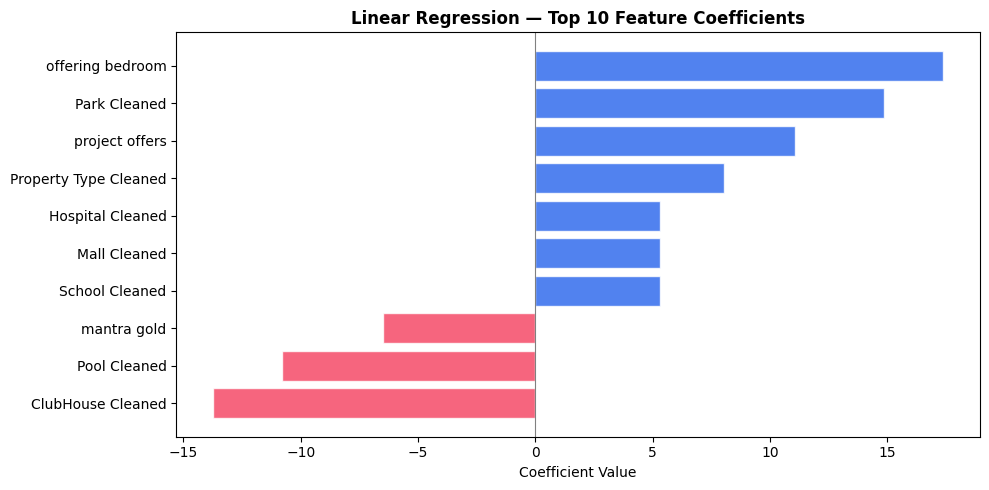

In [ ]:
# ── Train ──
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("=== Model 1: Linear Regression (Baseline) ===")
print(f"  Training R²: {lr.score(X_train, y_train):.4f}")
results = [evaluate_model("Linear Regression", y_test, y_pred_lr)]

# Coefficient analysis
coef_lr = show_coefficients(lr, X.columns, "Linear Regression")

## 5. Ridge Regression (L2 Regularization)

=== Ridge: Alpha Tuning (5-fold CV) ===
  α=0.01     → R² = 0.8254 ± 0.0118
  α=0.1      → R² = 0.8265 ± 0.0125
  α=1        → R² = 0.8306 ± 0.0150
  α=10       → R² = 0.8348 ± 0.0243
  α=100      → R² = 0.8280 ± 0.0329
  α=1000     → R² = 0.8252 ± 0.0353

  ⭐ Best α: 10

=== Model 2: Ridge (α=10) ===
  Training R²: 0.8630
  Ridge (α=10):
    RMSE: ₹15.60 lakhs | MAE: ₹10.59 lakhs | R²: 0.8548

  Ridge (α=10) — Top 10 Features by Coefficient Magnitude:
  Feature                              Coefficient
  --------------------------------------------------
  ClubHouse Cleaned                       -6.8401
  Property Type Cleaned               +     5.9308
  project offers                      +     5.1671
  Park Cleaned                        +     3.8089
  Pool Cleaned                            -3.4035
  School Cleaned                      +     3.1358
  Mall Cleaned                        +     3.1358
  Hospital Cleaned                    +     3.1358
  Gym Cleaned                    

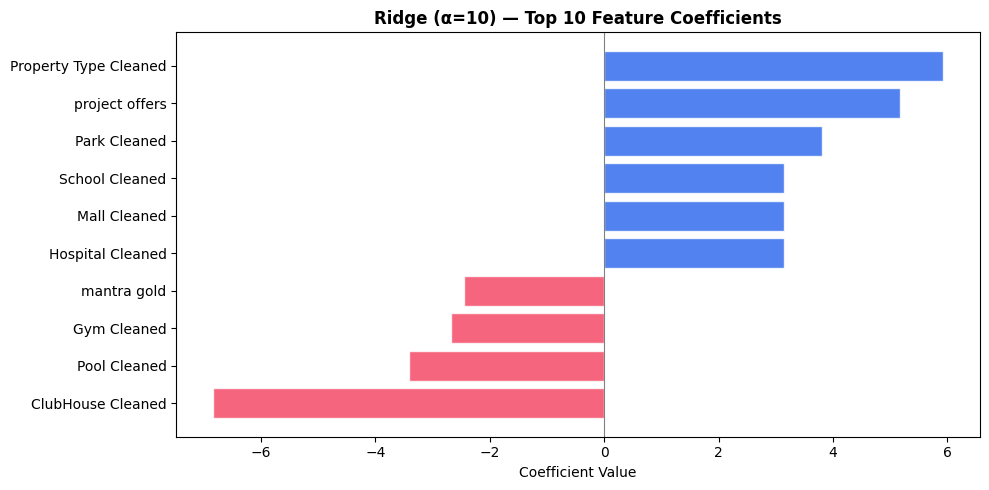

In [ ]:
# ── Tune alpha via cross-validation ──
alphas = [0.01, 0.1, 1, 10, 100, 1000]

print("=== Ridge: Alpha Tuning (5-fold CV) ===")
ridge_scores = []
for alpha in alphas:
    cv_scores = cross_val_score(Ridge(alpha=alpha), X_train, y_train, cv=5, scoring='r2')
    ridge_scores.append((alpha, cv_scores.mean(), cv_scores.std()))
    print(f"  α={alpha:<8} → R² = {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

best_alpha_ridge = max(ridge_scores, key=lambda x: x[1])[0]
print(f"\n  ⭐ Best α: {best_alpha_ridge}")

# Train with best alpha
ridge = Ridge(alpha=best_alpha_ridge)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

print(f"\n=== Model 2: Ridge (α={best_alpha_ridge}) ===")
print(f"  Training R²: {ridge.score(X_train, y_train):.4f}")
results.append(evaluate_model(f"Ridge (α={best_alpha_ridge})", y_test, y_pred_ridge))

# Coefficient analysis
coef_ridge = show_coefficients(ridge, X.columns, f"Ridge (α={best_alpha_ridge})")

## 6. Lasso Regression (L1 Regularization)

=== Lasso: Alpha Tuning (5-fold CV) ===
  α=0.01     → R² = 0.8258 ± 0.0123
  α=0.1      → R² = 0.8275 ± 0.0154
  α=1        → R² = 0.8241 ± 0.0310
  α=10       → R² = 0.8249 ± 0.0369
  α=100      → R² = 0.8147 ± 0.0463

  ⭐ Best α: 0.1

=== Model 3: Lasso (α=0.1) ===
  Training R²: 0.8682
  Lasso (α=0.1):
    RMSE: ₹15.61 lakhs | MAE: ₹11.19 lakhs | R²: 0.8546

  Lasso (α=0.1) — Top 10 Features by Coefficient Magnitude:
  Feature                              Coefficient
  --------------------------------------------------
  School Cleaned                      +    16.0296
  Park Cleaned                        +    11.4868
  ClubHouse Cleaned                      -10.7391
  project offers                      +     8.8856
  Property Type Cleaned               +     7.4566
  Pool Cleaned                            -6.4310
  offering bedroom                    +     4.1198
  mantra gold                             -2.3860
  Gym Cleaned                             -2.3551
  Adjective_Coun

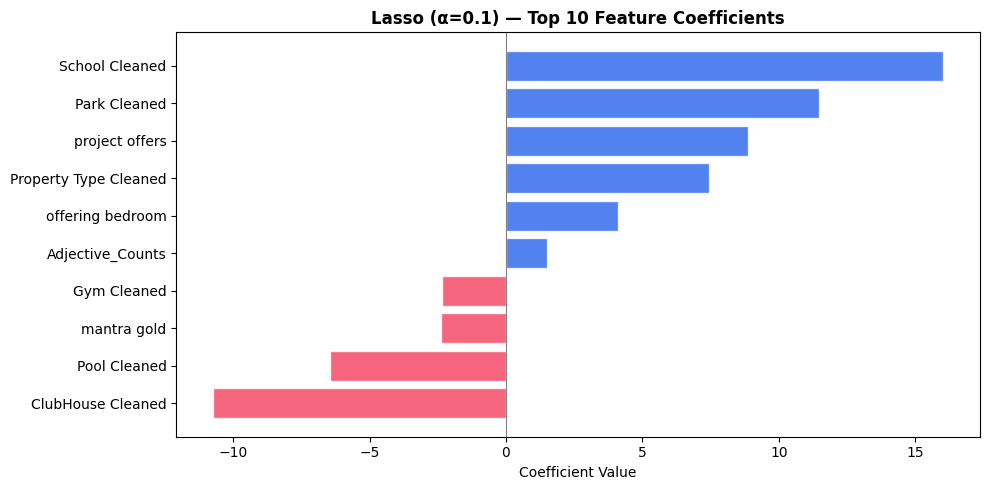


  Lasso feature selection: 18/25 features retained
  Features zeroed out: 7
  Removed features: ['bedroom apartment', 'boasts elegant', 'elegant towers', 'great community', 'project boasts', 'stories offering', 'towers stories']


In [ ]:
# ── Tune alpha ──
alphas_lasso = [0.01, 0.1, 1, 10, 100]

print("=== Lasso: Alpha Tuning (5-fold CV) ===")
lasso_scores = []
for alpha in alphas_lasso:
    cv_scores = cross_val_score(Lasso(alpha=alpha, max_iter=10000), X_train, y_train, cv=5, scoring='r2')
    lasso_scores.append((alpha, cv_scores.mean(), cv_scores.std()))
    print(f"  α={alpha:<8} → R² = {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

best_alpha_lasso = max(lasso_scores, key=lambda x: x[1])[0]
print(f"\n  ⭐ Best α: {best_alpha_lasso}")

# Train with best alpha
lasso = Lasso(alpha=best_alpha_lasso, max_iter=10000)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)

print(f"\n=== Model 3: Lasso (α={best_alpha_lasso}) ===")
print(f"  Training R²: {lasso.score(X_train, y_train):.4f}")
results.append(evaluate_model(f"Lasso (α={best_alpha_lasso})", y_test, y_pred_lasso))

# Coefficient analysis — see which features Lasso zeroed out
coef_lasso = show_coefficients(lasso, X.columns, f"Lasso (α={best_alpha_lasso})")

# Feature selection summary
n_nonzero = (lasso.coef_ != 0).sum()
n_total = len(lasso.coef_)
print(f"\n  Lasso feature selection: {n_nonzero}/{n_total} features retained")
print(f"  Features zeroed out: {n_total - n_nonzero}")
zeroed = [col for col, coef in zip(X.columns, lasso.coef_) if coef == 0]
if zeroed:
    print(f"  Removed features: {zeroed}")

## 7. Voting Regressor — Ensemble

In [ ]:
# ── Combine all three models ──
voting = VotingRegressor(estimators=[
    ('lr', LinearRegression()),
    ('ridge', Ridge(alpha=best_alpha_ridge)),
    ('lasso', Lasso(alpha=best_alpha_lasso, max_iter=10000))
])

voting.fit(X_train, y_train)
y_pred_voting = voting.predict(X_test)

print("=== Model 4: Voting Regressor (Ensemble) ===")
print(f"  Training R²: {voting.score(X_train, y_train):.4f}")
results.append(evaluate_model("Voting Regressor", y_test, y_pred_voting))

=== Model 4: Voting Regressor (Ensemble) ===
  Training R²: 0.8683
  Voting Regressor:
    RMSE: ₹15.65 lakhs | MAE: ₹11.12 lakhs | R²: 0.8539


## 8. Model Comparison


  MODEL COMPARISON


,name,rmse,mae,r2
0,Ridge (α=10),15.597843,10.589032,0.854811
1,Lasso (α=0.1),15.610284,11.194413,0.854580
2,Voting Regressor,15.648294,11.115330,0.853871
3,Linear Regression,15.876977,11.707953,0.849568


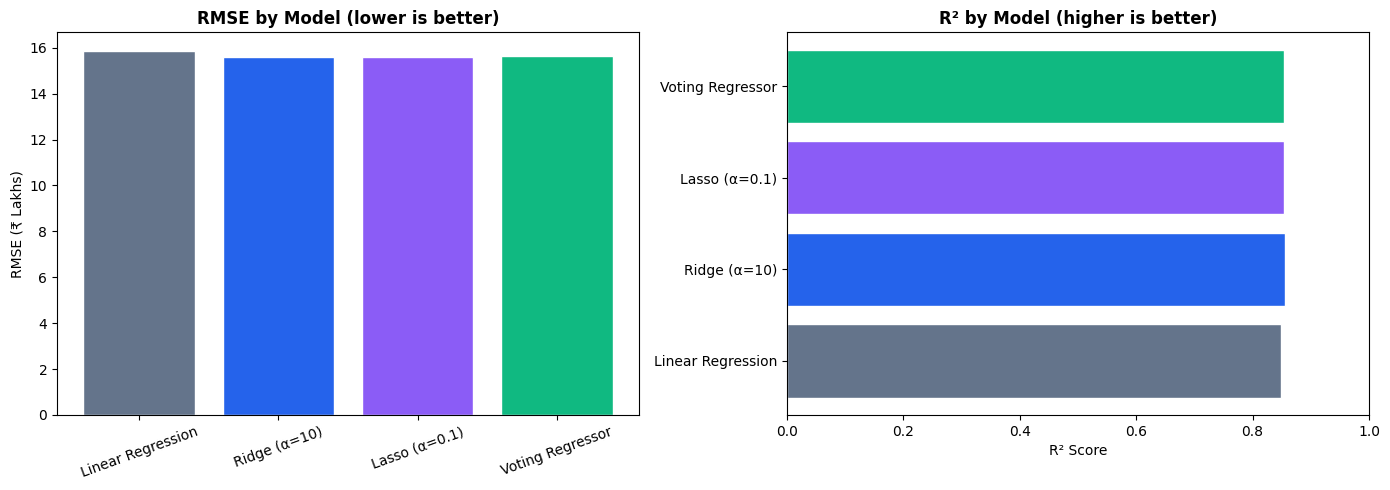

In [ ]:
# ── Compare all models ──
results_df = pd.DataFrame(results)
print("\n" + "=" * 65)
print("  MODEL COMPARISON")
print("=" * 65)
display(results_df.sort_values('r2', ascending=False).reset_index(drop=True))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#64748b', '#2563eb', '#8b5cf6', '#10b981']
axes[0].bar(results_df['name'], results_df['rmse'], color=colors, edgecolor='white')
axes[0].set_ylabel('RMSE (₹ Lakhs)')
axes[0].set_title('RMSE by Model (lower is better)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=20)

axes[1].barh(results_df['name'], results_df['r2'], color=colors, edgecolor='white')
axes[1].set_xlabel('R² Score')
axes[1].set_title('R² by Model (higher is better)', fontweight='bold')
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.show()

In [ ]:
# ── Bootstrap Confidence Intervals for RMSE ──
def bootstrap_rmse(y_true, y_pred, n_bootstrap=1000, confidence=0.95):
    """Compute bootstrap CI for RMSE."""
    rmse_scores = []
    n = len(y_true)
    for _ in range(n_bootstrap):
        idx = np.random.choice(n, n, replace=True)
        rmse_scores.append(np.sqrt(mean_squared_error(y_true[idx], y_pred[idx])))
    lower = np.percentile(rmse_scores, (1 - confidence) / 2 * 100)
    upper = np.percentile(rmse_scores, (1 + confidence) / 2 * 100)
    return np.mean(rmse_scores), lower, upper

print("=== 95% Bootstrap Confidence Intervals (RMSE) ===")
predictions = {
    'Linear Regression': y_pred_lr,
    f'Ridge (α={best_alpha_ridge})': y_pred_ridge,
    f'Lasso (α={best_alpha_lasso})': y_pred_lasso,
    'Voting Regressor': y_pred_voting,
}

for name, y_pred in predictions.items():
    mean_rmse, lower, upper = bootstrap_rmse(y_test, y_pred)
    print(f"  {name:30s} → RMSE: ₹{mean_rmse:.2f}L  [{lower:.2f}, {upper:.2f}]")

print("\n💡 Overlapping CIs → performance difference may not be statistically significant")

=== 95% Bootstrap Confidence Intervals (RMSE) ===
  Linear Regression              → RMSE: ₹15.66L  [10.65, 21.33]
  Ridge (α=10)                   → RMSE: ₹15.20L  [9.92, 21.45]
  Lasso (α=0.1)                  → RMSE: ₹15.46L  [10.11, 21.50]
  Voting Regressor               → RMSE: ₹15.39L  [10.01, 21.06]

💡 Overlapping CIs → performance difference may not be statistically significant


## 9. Per-Prediction Confidence Intervals

The business problem asks for a **price range**, not just a point estimate. Here we compute parametric prediction intervals using the residual standard error from training — each prediction gets its own [lower, upper] band.

In [ ]:
# ── Compute interval estimate from training residuals ──
def compute_interval_estimate(y_actual, y_predicted, pi=0.95):
    """
    Compute the interval width for prediction intervals based on
    the residual distribution from training data.

    Returns a dict with z_score and residual_std that can be applied
    to any new prediction.
    """
    residuals = y_actual - y_predicted
    residual_std = np.std(residuals)
    one_minus_pi = 1 - pi
    ppf_lookup = 1 - (one_minus_pi / 2)
    z_score = stats.norm.ppf(ppf_lookup)
    return {'z_score': z_score, 'residual_std': residual_std, 'pi': pi}

def get_prediction_interval(prediction, interval_est):
    """Apply interval estimate to a single prediction. Returns (lower, upper)."""
    margin = interval_est['z_score'] * interval_est['residual_std']
    return prediction - margin, prediction + margin

# Compute interval estimate from the Voting Regressor on training data
y_train_pred = voting.predict(X_train)
interval_est = compute_interval_estimate(y_train, y_train_pred, pi=0.95)

print(f"Interval Estimate (95% prediction interval):")
print(f"  Residual Std:  ₹{interval_est['residual_std']:.2f} lakhs")
print(f"  Z-score:       {interval_est['z_score']:.4f}")
print(f"  Margin:        ±₹{interval_est['z_score'] * interval_est['residual_std']:.2f} lakhs")

Interval Estimate (95% prediction interval):
  Residual Std:  ₹16.07 lakhs
  Z-score:       1.9600
  Margin:        ±₹31.49 lakhs



Interval Coverage on Test Set: 95.0% (target: 95%)


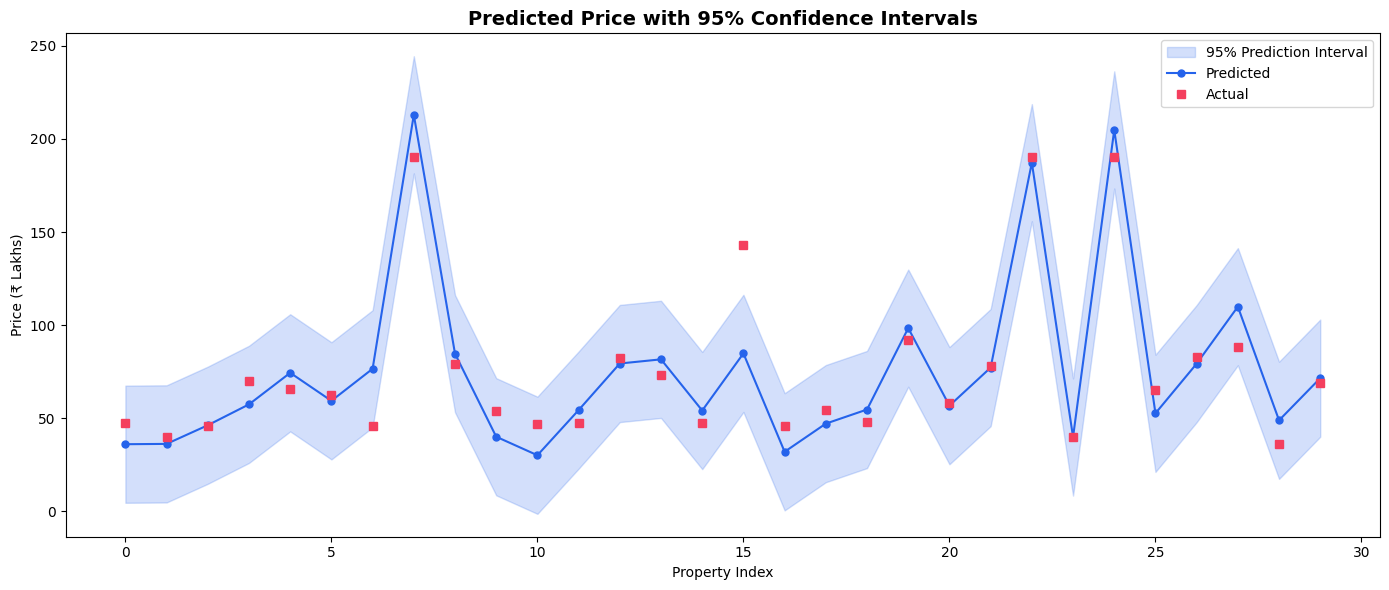


Sample Predictions (first 5):
      Actual  Predicted      Lower      Upper  In Range?
  ₹    47.3  ₹    35.9  ₹     4.4  ₹    67.4  ✅
  ₹    40.0  ₹    36.1  ₹     4.6  ₹    67.6  ✅
  ₹    45.5  ₹    46.1  ₹    14.6  ₹    77.6  ✅
  ₹    70.0  ₹    57.4  ₹    25.9  ₹    88.8  ✅
  ₹    65.5  ₹    74.3  ₹    42.8  ₹   105.8  ✅


In [ ]:
# ── Apply to test predictions ──
lower_bounds = []
upper_bounds = []

for pred in y_pred_voting:
    lo, hi = get_prediction_interval(pred, interval_est)
    lower_bounds.append(lo)
    upper_bounds.append(hi)

# Coverage: what % of actual values fall within the predicted intervals?
coverage = np.mean([lo <= actual <= hi for lo, hi, actual in zip(lower_bounds, upper_bounds, y_test)])
print(f"\nInterval Coverage on Test Set: {coverage:.1%} (target: {interval_est['pi']:.0%})")

# Visualize prediction intervals
fig, ax = plt.subplots(figsize=(14, 6))
n_show = min(30, len(y_test))
idx = np.arange(n_show)

ax.fill_between(idx, lower_bounds[:n_show], upper_bounds[:n_show],
                alpha=0.2, color='#2563eb', label='95% Prediction Interval')
ax.plot(idx, y_pred_voting[:n_show], 'o-', color='#2563eb', markersize=5, label='Predicted')
ax.plot(idx, y_test[:n_show], 's', color='#f43f5e', markersize=6, label='Actual')
ax.set_xlabel('Property Index')
ax.set_ylabel('Price (₹ Lakhs)')
ax.set_title('Predicted Price with 95% Confidence Intervals', fontweight='bold', fontsize=14)
ax.legend()
plt.tight_layout()
plt.show()

# Sample predictions with intervals
print(f"\nSample Predictions (first 5):")
print(f"  {'Actual':>10s} {'Predicted':>10s} {'Lower':>10s} {'Upper':>10s} {'In Range?':>10s}")
for i in range(5):
    in_range = "✅" if lower_bounds[i] <= y_test[i] <= upper_bounds[i] else "❌"
    print(f"  ₹{y_test[i]:>8.1f}  ₹{y_pred_voting[i]:>8.1f}  ₹{lower_bounds[i]:>8.1f}  ₹{upper_bounds[i]:>8.1f}  {in_range}")

## 10. Cross-Validation

In [ ]:
# ── 5-Fold CV for the Voting Regressor ──
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_r2 = cross_val_score(voting, X, y, cv=kf, scoring='r2')
cv_rmse = -cross_val_score(voting, X, y, cv=kf, scoring='neg_root_mean_squared_error')

print("=== 5-Fold Cross-Validation: Voting Regressor ===")
for fold, (r2, rmse) in enumerate(zip(cv_r2, cv_rmse), 1):
    print(f"  Fold {fold}: R² = {r2:.4f}, RMSE = ₹{rmse:.2f}L")

print(f"\n  Average R²:   {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")
print(f"  Average RMSE: ₹{cv_rmse.mean():.2f}L ± ₹{cv_rmse.std():.2f}L")

=== 5-Fold Cross-Validation: Voting Regressor ===
  Fold 1: R² = 0.8539, RMSE = ₹15.65L
  Fold 2: R² = 0.8287, RMSE = ₹20.23L
  Fold 3: R² = 0.7887, RMSE = ₹17.80L
  Fold 4: R² = 0.8401, RMSE = ₹18.06L
  Fold 5: R² = 0.8577, RMSE = ₹16.27L

  Average R²:   0.8338 ± 0.0248
  Average RMSE: ₹17.60L ± ₹1.60L


## 11. Model Serialization

In [ ]:
# ── Save the trained model and interval estimate ──
import os
os.makedirs('model', exist_ok=True)

# Save the Voting Regressor model
model_path = 'model/property_price_prediction_voting.sav'
joblib.dump(voting, model_path)
print(f"✅ Model saved: {model_path} ({os.path.getsize(model_path)/1024:.0f} KB)")

# Save the interval estimate for inference
pickle.dump(interval_est, open('model/interval_est.pkl', 'wb'))
print(f"✅ Interval estimate saved: model/interval_est.pkl")

print(f"\nAll model artifacts in model/ directory:")
for f in os.listdir('model'):
    size = os.path.getsize(f'model/{f}') / 1024
    print(f"  {f:45s} ({size:.0f} KB)")

✅ Model saved: model/property_price_prediction_voting.sav (5 KB)
✅ Interval estimate saved: model/interval_est.pkl

All model artifacts in model/ directory:
  sub_area_price_map.pkl                        (1 KB)
  feature_cols.pkl                              (0 KB)
  amenities_score_price_map.pkl                 (0 KB)
  interval_est.pkl                              (0 KB)
  all_feature_names.pkl                         (0 KB)
  property_price_prediction_voting.sav          (5 KB)
  count_vectorizer.pkl                          (1 KB)


## 12. Standalone Inference Pipeline

Before wrapping the model in a FastAPI endpoint (Lab 4), let's verify the **complete inference path** works end-to-end: raw property data → preprocessing → feature creation → vectorization → prediction → confidence interval.

This is the logic that Lab 4's `src/inference.py` will encapsulate. Understanding it as a standalone pipeline first makes the API integration clearer.

In [ ]:
# ── Load all artifacts (as if we're starting fresh) ──
model = joblib.load('model/property_price_prediction_voting.sav')
vectorizer = pickle.load(open('model/count_vectorizer.pkl', 'rb'))
sub_area_map = pickle.load(open('model/sub_area_price_map.pkl', 'rb'))
amenities_map = pickle.load(open('model/amenities_score_price_map.pkl', 'rb'))
interval_est = pickle.load(open('model/interval_est.pkl', 'rb'))

print("✅ All 5 artifacts loaded for inference")
print(f"   Model: {type(model).__name__}")
print(f"   Vectorizer vocabulary: {len(vectorizer.vocabulary_)} bigrams")
print(f"   Sub-area mappings: {len(sub_area_map)} areas")
print(f"   Amenities mappings: {len(amenities_map)} score levels")
print(f"   Interval estimate: ±₹{interval_est['z_score'] * interval_est['residual_std']:.2f}L")

✅ All 5 artifacts loaded for inference
   Model: VotingRegressor
   Vectorizer vocabulary: 10 bigrams
   Sub-area mappings: 34 areas
   Amenities mappings: 5 score levels
   Interval estimate: ±₹31.49L


In [ ]:
# ── Define the inference pipeline as a function ──
import re
from nltk.tokenize import word_tokenize
from nltk import pos_tag
import nltk

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('stopwords', quiet=True)


REPLACE_BY_SPACE = re.compile("[/(){}\[\]\|@,;!]")
BAD_SYMBOLS = re.compile("[^0-9a-z #+_]")

from nltk.corpus import stopwords as sw
STOPWORDS = set(sw.words('english'))

def run_inference(property_type, area, sub_area, description,
                  clubhouse, school, hospital, mall, park, pool, gym):
    """
    Complete inference pipeline: raw input → prediction + confidence interval.

    This is the exact logic that app.py will call via src/inference.py.
    """
    # Step 1: Text preprocessing
    text = str(description).lower()
    text = REPLACE_BY_SPACE.sub(' ', text)
    text = BAD_SYMBOLS.sub('', text)
    text = ' '.join(w for w in text.split() if w not in STOPWORDS and len(w) > 2)

    # Step 2: POS counts
    tokens = word_tokenize(text)
    tagged = pos_tag(tokens)
    noun_count = sum(1 for _, t in tagged if t in ('NN', 'NNS', 'NNP'))
    verb_count = sum(1 for _, t in tagged if t.startswith('VB'))
    adj_count = sum(1 for _, t in tagged if t in ('JJ', 'JJR', 'JJS'))

    # Step 3: Target encoding lookups
    sub_area_clean = str(sub_area).lower().strip()
    price_by_subarea = sub_area_map.get(sub_area_clean, np.mean(list(sub_area_map.values())))

    amenity_list = [clubhouse, school, hospital, mall, park, pool, gym]
    amenity_score = sum(amenity_list)
    price_by_amenities = amenities_map.get(amenity_score, np.mean(list(amenities_map.values())))

    # Step 4: Vectorize description
    text_features = vectorizer.transform([text]).toarray()[0]

    # Step 5: Assemble feature vector (same order as training!)
    structural = [property_type, area,
                  clubhouse, school, hospital, mall, park, pool, gym,
                  price_by_subarea, amenity_score, price_by_amenities,
                  noun_count, verb_count, adj_count]

    feature_vector = np.array(structural + text_features.tolist()).reshape(1, -1)

    # Step 6: Predict
    prediction = model.predict(feature_vector)[0]

    # Step 7: Confidence interval
    lower, upper = get_prediction_interval(prediction, interval_est)

    return {
        'predicted_price': round(prediction, 2),
        'lower_bound': round(max(0, lower), 2),
        'upper_bound': round(upper, 2),
        'features_used': feature_vector.shape[1],
    }

In [ ]:
# ── Test the inference pipeline with sample properties ──
print("=" * 65)
print("  INFERENCE PIPELINE TEST")
print("=" * 65)

test_cases = [
    {"property_type": 2, "area": 1200, "sub_area": "kothrud",
     "description": "Spacious 2 BHK apartment with modular kitchen and garden view in gated community",
     "clubhouse": 1, "school": 1, "hospital": 0, "mall": 0, "park": 1, "pool": 0, "gym": 1},

    {"property_type": 3, "area": 2000, "sub_area": "baner",
     "description": "Premium 3 BHK flat offering world class amenities swimming pool gym club house",
     "clubhouse": 1, "school": 1, "hospital": 1, "mall": 1, "park": 1, "pool": 1, "gym": 1},

    {"property_type": 1, "area": 600, "sub_area": "hadapsar",
     "description": "Compact 1 BHK near IT park basic amenities available",
     "clubhouse": 0, "school": 0, "hospital": 0, "mall": 0, "park": 0, "pool": 0, "gym": 0},
]

for i, tc in enumerate(test_cases, 1):
    result = run_inference(**tc)
    print(f"\n  Property {i}: {tc['property_type']} BHK, {tc['area']} sqft, {tc['sub_area']}")
    print(f"    Predicted: ₹{result['predicted_price']:.2f} lakhs")
    print(f"    Range:     ₹{result['lower_bound']:.2f} – ₹{result['upper_bound']:.2f} lakhs")
    print(f"    Features:  {result['features_used']} dimensions")

print(f"\n✅ Inference pipeline works end-to-end")
print(f"   This exact logic will be wrapped in FastAPI in Lab 4")

  INFERENCE PIPELINE TEST

  Property 1: 2 BHK, 1200 sqft, kothrud
    Predicted: ₹121.22 lakhs
    Range:     ₹89.73 – ₹152.71 lakhs
    Features:  25 dimensions

  Property 2: 3 BHK, 2000 sqft, baner
    Predicted: ₹194.47 lakhs
    Range:     ₹162.98 – ₹225.96 lakhs
    Features:  25 dimensions

  Property 3: 1 BHK, 600 sqft, hadapsar
    Predicted: ₹46.04 lakhs
    Range:     ₹14.54 – ₹77.53 lakhs
    Features:  25 dimensions

✅ Inference pipeline works end-to-end
   This exact logic will be wrapped in FastAPI in Lab 4


In [ ]:
!zip -r models.zip model/ model_features.csv model_target.npy

  adding: model/ (stored 0%)
  adding: model/sub_area_price_map.pkl (deflated 29%)
  adding: model/feature_cols.pkl (deflated 40%)
  adding: model/amenities_score_price_map.pkl (deflated 3%)
  adding: model/interval_est.pkl (deflated 13%)
  adding: model/all_feature_names.pkl (deflated 43%)
  adding: model/property_price_prediction_voting.sav (deflated 59%)
  adding: model/count_vectorizer.pkl (deflated 40%)
  adding: model_features.csv (deflated 86%)
  adding: model_target.npy (deflated 62%)


---

## 13. Conclusion & Next Steps

| Task | Key Takeaway |
|------|-------------|
| **Linear Regression** | Baseline — always start here for interpretability |
| **Coefficient analysis** | "Price by sub-area" is the strongest predictor; Lasso zeros out weak bigrams |
| **Ridge (L2)** | Shrinks all coefficients — handles correlated NLP features well |
| **Lasso (L1)** | Zeros out irrelevant features — automatic feature selection |
| **Voting Regressor** | Averages diverse models — reduces uncorrelated errors |
| **Bootstrap CIs** | Quantify model-level uncertainty (overlapping CIs → not significantly different) |
| **Per-prediction intervals** | Deliver price *ranges* — the actual business requirement |
| **Inference pipeline** | 7-step path from raw input to prediction + interval using 5 artifacts |

### Model Artifacts Produced

| File | Contents | Used By |
|------|----------|---------|
| `model/property_price_prediction_voting.sav` | Trained Voting Regressor | Lab 4 (FastAPI) |
| `model/count_vectorizer.pkl` | Fitted CountVectorizer (bigrams) | Lab 4 (inference) |
| `model/sub_area_price_map.pkl` | Sub-area → avg price mapping | Lab 4 (inference) |
| `model/amenities_score_price_map.pkl` | Amenity score → avg price mapping | Lab 4 (inference) |
| `model/interval_est.pkl` | Z-score + residual std for intervals | Lab 4 (inference) |

### Try on Your Own
1. Add Elastic Net (`sklearn.linear_model.ElasticNet`) — how do its coefficients compare to Ridge vs Lasso?
2. Plot residuals (predicted - actual) for each model — look for systematic patterns
3. Try 99% prediction intervals — how much wider are the bands vs 95%?
4. Remove the target-encoded features and retrain — how much does R² drop?

---

**Next Lab:** Module 2, Lab 4 — FastAPI Model Serving ⚡